In [74]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
# %matplotlib widget
%matplotlib inline


In [75]:
from scipy.constants import c, k

In [76]:
distance = np.linspace(100, 4000, 100) * 1e3

In [77]:
center_freq = 436.5e6

In [78]:
def fspl_db(d, f):
    fspl = 20 * np.log10(d) + 20 * np.log10(f) - 147.55
    return fspl

In [79]:
fspl = fspl_db(distance, center_freq)

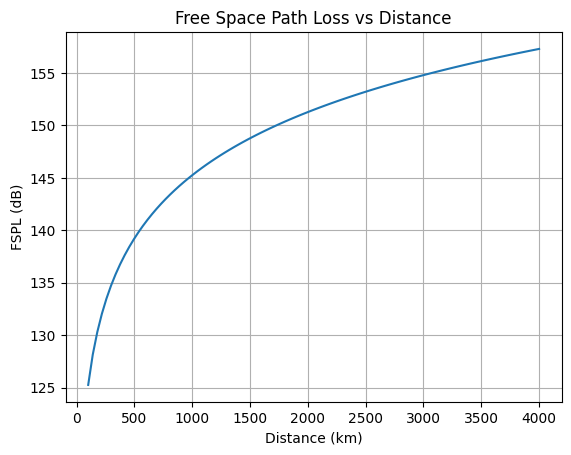

In [80]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(distance / 1e3, fspl)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('FSPL (dB)')
ax.set_title('Free Space Path Loss vs Distance')
ax.grid()
plt.show()

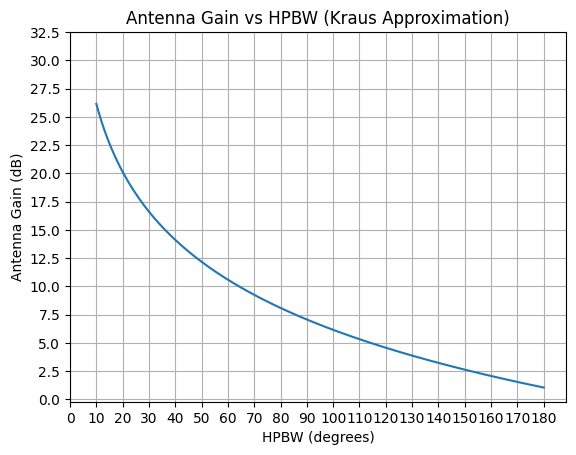

In [81]:
def antenna_gain_kraus_db(hpbw_deg):
  gain = 360**2 / np.pi / hpbw_deg**2
  gain_db = 10 * np.log10(gain)
  return gain_db

def antenna_hpbw_kraus_db(gain_db):
  gain = 10**(gain_db / 10)
  hpbw_deg = np.sqrt(360**2 / np.pi / gain)
  return hpbw_deg

antenna_gain_db = np.arange(0, 30+1, 1)
antenna_hpbw_deg = np.arange(10, 180+1, 1)
max_slant_angle_deg = 90 - antenna_hpbw_deg / 2

antenna_gain = antenna_gain_kraus_db(antenna_hpbw_deg)

fig = plt.figure()
ax = plt.subplot(111)
# ax.plot(antenna_gain_db, antenna_hpbw_kraus_db(antenna_gain_db))
ax.plot(antenna_hpbw_deg, antenna_gain)
ax.set_ylabel('Antenna Gain (dB)')
ax.set_xlabel('HPBW (degrees)')
ax.set_title('Antenna Gain vs HPBW (Kraus Approximation)')
ax.set_xticks(np.arange(0, 190, 10))
ax.set_yticks(np.arange(0, 35, 2.5))
ax.grid()
plt.show()


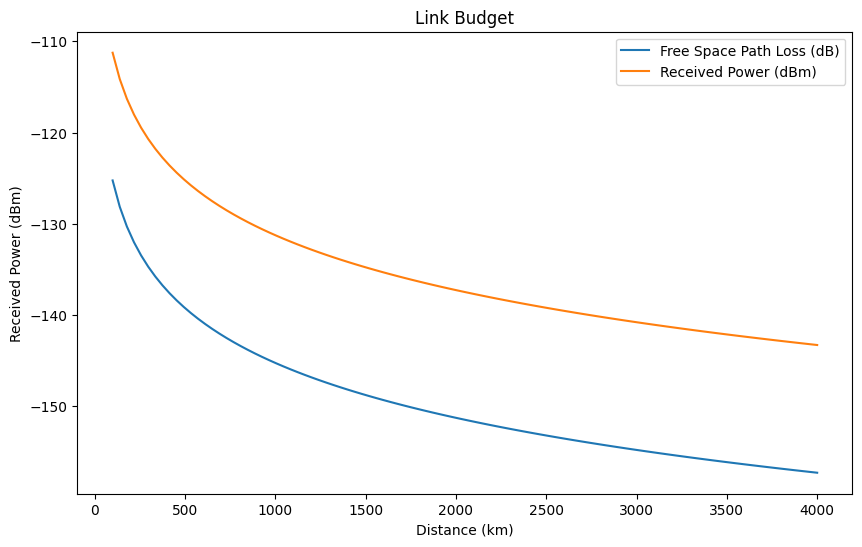

In [82]:
tx_power_dbm = 13
gains = [
  ("tx power [dBm]", tx_power_dbm),
  ("tx antenna gain [dBi]", 0),
  ("rx antenna gain [dBi]", 11),
]
main_losses = [
  ("free space path loss [dB]", -fspl)
]
additional_losses = [
  ("polarization mismatch [dB]", -3),
  ("implementation loss [dB]", -4),
  ("pointing loss [dB]", -3),
]

rx_power_dbm = sum(loss[1] for loss in gains) + sum(loss[1] for loss in main_losses) + sum(loss[1] for loss in additional_losses)
plt.figure(figsize=(10, 6))
plt.plot(distance / 1e3, -fspl, label='Free Space Path Loss (dB)')
plt.plot(distance / 1e3, rx_power_dbm, label='Received Power (dBm)')
plt.xlabel('Distance (km)')
plt.ylabel('Received Power (dBm)')
plt.title('Link Budget')
plt.legend()
plt.show()

In [83]:
lora_params = {
  "bw": [
    62.5*1e3,
    125*1e3,
    250*1e3,
    # 500*1e3,
  ],
  "cr": [1, 2, 3, 4],
  "sf": [7, 8, 9, 10, 11, 12]
}
lora_snr_limits_db = {
  "sf7": {"snr_limit": -7.5},
  "sf8": {"snr_limit": -10.0},
  "sf9": {"snr_limit": -12.5},
  "sf10": {"snr_limit": -15.0},
  "sf11": {"snr_limit": -17.5},
  "sf12": {"snr_limit": -20.0},
}

In [84]:
def processing_gain_db(sf, bw, cr = 1):
  rs = bw / (2 ** sf)
  rc = rs * 2 ** sf
  rb = sf * (4 / (4 + cr)) / (2 ** sf / bw)
  return 10 * np.log10(rc / rb)

In [85]:
noise_temp_c = np.linspace(0, 100, 100)
noise_temp_k = noise_temp_c + 273.15
bandwidth_hz = np.array(lora_params["bw"]) 
noise_power_dbm = 10 * np.log10(noise_temp_k[:, np.newaxis] * bandwidth_hz[np.newaxis, :] * k)
noise_power_dbm += 30 # Convert from dBW to dBm
noise_power_dbm_25C = noise_power_dbm[25, :]
dnoise_temp_dbm = np.diff(noise_power_dbm, axis=0)
print(f"Noise Power sensitivity (dB per °C): {dnoise_temp_dbm.mean():.2f} dB/°C")
print(f"Noise Power at 25°C (dBm): {noise_power_dbm_25C}")

Noise Power sensitivity (dB per °C): 0.01 dB/°C
Noise Power at 25°C (dBm): [-125.89234206 -122.8820421  -119.87174215]


SNR bandwidth for SF7: [1281.81818182  887.87878788  651.51515152] km
SNR bandwidth for SF8: [1715.15151515 1203.03030303  848.48484848] km
SNR bandwidth for SF9: [2266.66666667 1596.96969697 1124.24242424] km
SNR bandwidth for SF10: [3054.54545455 2148.48484848 1518.18181818] km
SNR bandwidth for SF11: [4000.         2857.57575758 2030.3030303 ] km
SNR bandwidth for SF12: [4000.         3803.03030303 2700.        ] km


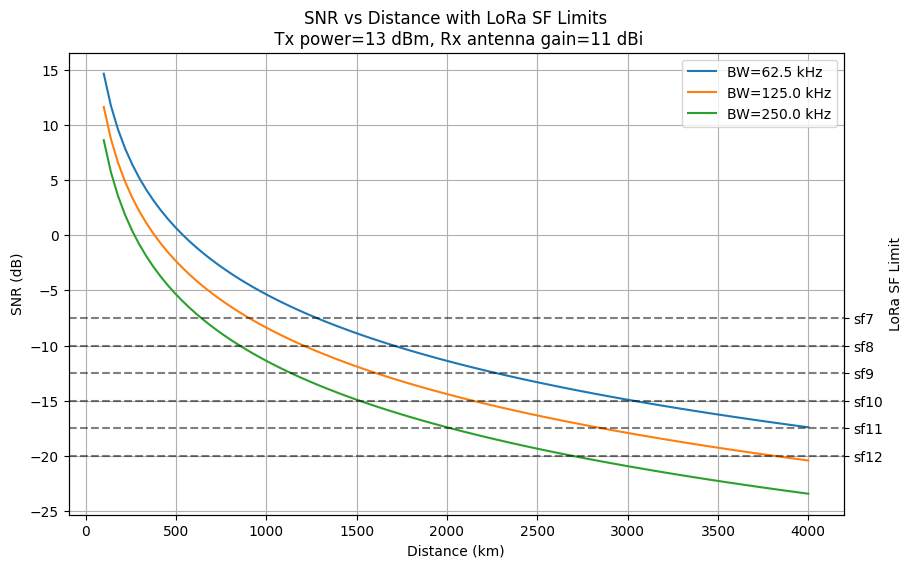

In [86]:
snr_db = rx_power_dbm - noise_power_dbm_25C[:, np.newaxis]

fig = plt.figure(figsize=(10, 6))
ax_snr = plt.subplot(1, 1, 1)
ax_sf = ax_snr.twinx()
ax_snr.plot(distance / 1e3, snr_db.T, label='SNR (dB)')
ax_snr.legend([f"BW={bw/1e3:.1f} kHz" for bw in lora_params["bw"]])
sf_ticks = []
sf_tick_labels = []
for i, sf in enumerate(lora_params["sf"]):
  snr_limit_db = lora_snr_limits_db[f"sf{sf}"]["snr_limit"]
  ax_sf.axhline(snr_limit_db, linestyle='--', alpha=0.5, color='k')
  sf_tick_labels.append(f"sf{sf}")
  sf_ticks.append(snr_limit_db)
  snr_bw = np.argmin(np.abs(snr_db - snr_limit_db), axis=1)
  print(f"SNR bandwidth for SF{sf}: {distance[snr_bw]/1e3} km")
ax_sf.set_yticks(sf_ticks)
ax_sf.set_yticklabels(sf_tick_labels)
ax_sf.set_ylim(ax_snr.get_ylim())
ax_snr.grid()

ax_snr.set_xlabel('Distance (km)')
ax_snr.set_ylabel('SNR (dB)')
ax_sf.set_ylabel('LoRa SF Limit')
ax_snr.set_title(f'SNR vs Distance with LoRa SF Limits\n Tx power={tx_power_dbm} dBm, Rx antenna gain={gains[2][1]} dBi')

plt.show()